# 06 – Modelselectie op 2024: modellen vergelijken en fouten analyseren

| | |
|---|---|
| **Auteur(s)** | Kobe Vandenberk |
| **Wat** | Alle modellen uit 05a–05e naast elkaar leggen, nagaan welke verschillen echt zijn (en welke ruis), en onderzoeken **waar** het beste model zich vergist. |
| **Input** | `models/2024/metrics/*.json`, `models/2024/predictions/*.parquet`, `data/2024/model_table.parquet` |
| **Output** | conclusie + keuze van het gedeployde model |
| **GenAI** | Code en tekst opgesteld met hulp van Claude; keuzes en resultaten nagekeken door Kobe. |

> **Studie op 2024 (modelselectie).** Dit notebook werkt op één jaar (2024) om snel en grondig te kiezen welke techniek het best werkt. De gekozen techniek wordt daarna op alle data (2013–2026) getraind: zie `02b_eda_all_years`, `04_prepare_data` en `07`–`09`.

## 0. Imports en resultaten inlezen

In [1]:
%matplotlib inline
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import citibike as cb

table = cb.load_model_table(cb.DATA_2024 / "model_table.parquet")
metrics = {p.stem: json.loads(p.read_text(encoding="utf-8")) for p in sorted(cb.METRICS_2024.glob("*.json"))
           if p.stem != "deployed"}
preds = {p.stem: pd.read_parquet(p) for p in sorted(cb.PRED_2024.glob("*.parquet"))}
print("Modellen:", list(metrics))

Modellen: ['baseline', 'hgb_with_lags', 'hist_gradient_boosting', 'poisson_glm', 'pycaret', 'quick_hgb', 'random_forest']


## 1. Overzichtstabel
- **cv_mae**: gemiddelde MAE over de 5 week-folds van de trainset (hiermee kozen en tunden we);
- **test_***: de eenmalige meting op de testset (laatste 7 dagen van elke maand).

`hgb_with_lags` staat apart: dat model gebruikt informatie die de API niet heeft (zie 05e) en is dus geen kandidaat voor de deployment.

In [2]:
order = ["baseline", "poisson_glm", "random_forest", "pycaret", "quick_hgb", "hist_gradient_boosting", "hgb_with_lags"]
order += [name for name in metrics if name not in order]          # bv. een AWS-model van een teamgenoot
overview = pd.DataFrame({name: {"model": m["model"], "cv_mae": m.get("cv_mae_mean"),
                                "test_mae": m["test_mae"], "test_rmse": m["test_rmse"], "test_r2": m["test_r2"],
                                "test_poisson_dev": m["test_poisson_deviance"],
                                "fit_s (5 folds)": m.get("cv_fit_seconds")}
                         for name, m in metrics.items()}).T.reindex([o for o in order if o in metrics])
overview

,model,cv_mae,test_mae,test_rmse,test_r2,test_poisson_dev,fit_s (5 folds)
baseline,Baseline: gemiddelde per zone x uur x weekend,59.1855,59.2751,96.4412,0.7235,34.1876,0.1
poisson_glm,"Poisson-GLM (zone x uur x weekend, spline temp...",30.4538,33.1892,60.3971,0.8916,14.5894,12.1
random_forest,Random forest (getuned (ronde 2)),27.3988,30.316,58.94,0.8967,13.971,41.0
pycaret,PyCaret: ExtraTreesRegressor (getuned),26.6368,30.5775,59.9382,0.8932,14.5678,None
quick_hgb,"HistGradientBoosting (Poisson, standaard)",27.5663,30.8826,57.1495,0.9029,13.3123,5.4
hist_gradient_boosting,"HistGradientBoosting (Poisson, getuned)",24.8879,29.0454,56.3468,0.9056,12.5921,77.9
hgb_with_lags,HistGradientBoosting + lag 24h/168h (niet depl...,27.4698,26.8966,51.0475,0.9225,10.3574,86.1


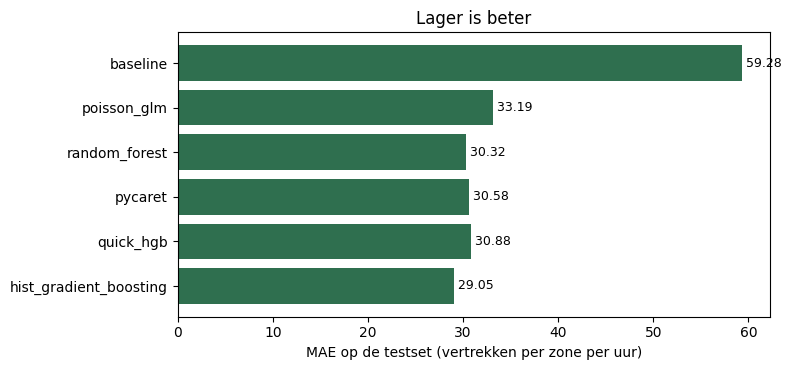

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.8))
plot = overview.drop(index="hgb_with_lags", errors="ignore")
ax.barh(plot.index, plot["test_mae"].astype(float), color="#2f6f4f")
for i, v in enumerate(plot["test_mae"].astype(float)):
    ax.text(v, i, f" {v:.2f}", va="center", fontsize=9)
ax.set(xlabel="MAE op de testset (vertrekken per zone per uur)", title="Lager is beter")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretatie:**
- Alle "echte" modellen halveren de fout van de baseline (MAE 59 naar 29–33). De grootste winst zit dus in de keuze van kenmerken en een model dat interacties kan leren, niet in de fijnafstemming.
- **De getunede HistGradientBoosting is het beste deploybare model**: laagste CV-MAE (24,9), laagste test-MAE (29,0), hoogste R² (0,906) en laagste Poisson-deviance.
- Daarna volgen random forest (30,3), PyCaret's Extra Trees (30,6) en het snelle ongetunede boosting-model (30,9), dicht bij elkaar. Het GLM (33,2) is het zwakst van de echte modellen, maar wel het enige met uitlegbare coëfficiënten.
- Alleen het model met lags (niet deploybaar) is beter op de testset, maar in de CV slechter (zie 05e).
- Bij alle modellen is de testfout hoger dan de CV-fout. Hieronder zoeken we waarom.

## 2. Zijn de verschillen echt?
Twee modellen die 0,1 in MAE verschillen, kunnen even goed zijn: met een andere testweek was de volgorde misschien omgekeerd. We kijken op twee manieren.

**a) Per fold (cross-validatie).** Alle sklearn-modellen gebruikten exact dezelfde 5 week-folds (`GroupKFold` is deterministisch). Wint het beste model in **elke** fold, dan is het verschil robuust.

In [4]:
fold_table = pd.DataFrame({name: m["cv_mae"] for name, m in metrics.items() if "cv_mae" in m},
                          index=[f"fold {i}" for i in range(5)])
fold_table = fold_table[[c for c in order if c in fold_table]]
best_name = "hist_gradient_boosting"
wins = {c: int((fold_table[best_name] < fold_table[c]).sum()) for c in fold_table if c not in (best_name, "hgb_with_lags")}
display(fold_table.round(3))
print(f"Aantal folds (van 5) waarin {best_name} beter is dan:", wins)

,baseline,poisson_glm,random_forest,quick_hgb,hist_gradient_boosting,hgb_with_lags
fold 0,60.574,29.552,27.190,27.832,24.715,26.121
fold 1,58.487,31.820,29.863,28.360,26.581,29.400
fold 2,69.989,27.661,23.998,25.592,22.729,28.342
fold 3,52.398,31.287,29.603,28.042,25.330,25.927
fold 4,54.480,31.949,26.341,28.005,25.084,27.559


Aantal folds (van 5) waarin hist_gradient_boosting beter is dan: {'baseline': 5, 'poisson_glm': 5, 'random_forest': 5, 'quick_hgb': 5}


**b) Bootstrap op de testset, per dag.** Opeenvolgende uren hangen samen (een regenachtige dag geeft overal fouten), dus we hertrekken **hele dagen** in plaats van losse uren (*block bootstrap*). 2.000 keer: hoe vaak is het verschil in MAE in het voordeel van het beste model, en wat is het 95%-interval?

In [5]:
def paired_bootstrap(a: str, b: str, n: int = 2000, seed: int = cb.SEED):
    pa, pb = preds[a], preds[b]
    err = pd.DataFrame({"day": pa["time"].dt.normalize(), "a": (pa["trips"] - pa["pred"]).abs(),
                        "b": (pb["trips"] - pb["pred"]).abs()})
    per_day = err.groupby("day")[["a", "b"]].agg(["sum", "count"])
    sums_a, sums_b, counts = per_day[("a", "sum")].to_numpy(), per_day[("b", "sum")].to_numpy(), per_day[("a", "count")].to_numpy()
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(per_day), size=(n, len(per_day)))
    diff = sums_b[idx].sum(1) / counts[idx].sum(1) - sums_a[idx].sum(1) / counts[idx].sum(1)
    return {"MAE-winst van " + a: round(float(diff.mean()), 3), "95%-BI": np.round(np.percentile(diff, [2.5, 97.5]), 3).tolist(),
            "P(beter)": round(float((diff > 0).mean()), 3)}

pd.DataFrame({other: paired_bootstrap(best_name, other) for other in order if other not in (best_name, "hgb_with_lags")
              if other in preds}).T

,MAE-winst van hist_gradient_boosting,95%-BI,P(beter)
baseline,30.156,"[24.731, 35.694]",1.0
poisson_glm,4.143,"[2.398, 5.837]",1.0
random_forest,1.283,"[0.184, 2.519]",0.989
pycaret,1.542,"[0.269, 2.952]",0.995
quick_hgb,1.839,"[0.998, 2.641]",1.0


**Interpretatie:**
- **Per fold**: de getunede boosting wint in **5 van de 5** folds van elk ander deploybaar model. De voorsprong is dus niet het toeval van één week.
- **Bootstrap per dag op de testset**: tegenover de baseline (+30 vertrekken/uur), het GLM (+4,1) en het snelle model (+1,8) is het verschil overtuigend. Tegenover random forest (+1,3, 95%-BI 0,2 tot 2,5) en Extra Trees (+1,5, BI 0,3 tot 3,0) is het verschil klein: het interval ligt net boven 0. Echt, maar bescheiden.
- Praktisch geeft dat de doorslag voor boosting: het is het beste, én het model is klein (4,7 MB) en snel, en draait met scikit-learn alleen (geen extra pakketten op de server).

## 3. Foutenanalyse van het gekozen model
We nemen de testvoorspellingen van de getunede gradient boosting en zoeken **waar** de fouten zitten.

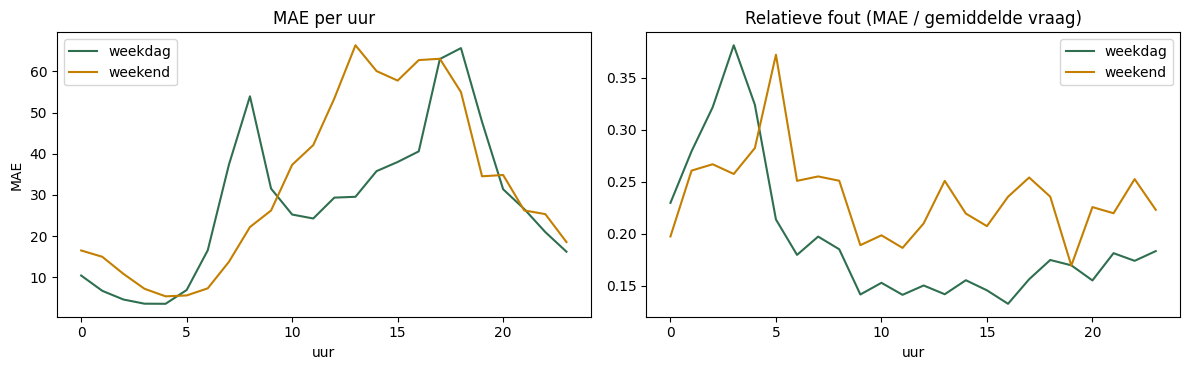

In [6]:
res = preds[best_name].merge(table[["zone", "time", "precipitation_mm", "temperature_c"]], on=["zone", "time"])
res["error"] = res["pred"] - res["trips"]            # > 0: model overschat
res["abs_error"] = res["error"].abs()
res["hour"], res["weekend"] = res["time"].dt.hour, res["time"].dt.dayofweek >= 5

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
by_hour = res.groupby(["hour", "weekend"])[["abs_error", "trips"]].mean().unstack()
by_hour["abs_error"].plot(ax=axes[0], color=["#2f6f4f", "#c47f00"])
axes[0].set(title="MAE per uur", xlabel="uur", ylabel="MAE"); axes[0].legend(["weekdag", "weekend"])
(by_hour["abs_error"] / by_hour["trips"]).plot(ax=axes[1], color=["#2f6f4f", "#c47f00"])
axes[1].set(title="Relatieve fout (MAE / gemiddelde vraag)", xlabel="uur"); axes[1].legend(["weekdag", "weekend"])
plt.tight_layout()
plt.show()

**Interpretatie:**
- In **absolute** termen zit de grootste fout in de **spits** (weekdag 8u en 17–18u) en midden op de dag in het weekend: daar zijn er ook de meeste vertrekken.
- In **relatieve** termen is het omgekeerd: 's nachts (1u–5u) is de fout 25 tot 38% van de vraag. Bij een handvol vertrekken per uur is het toeval groot (Poisson-ruis); dat kan geen enkel model voorspellen, en voor herverdeling is het ook onbelangrijk.
- Het **weekend** is overdag relatief moeilijker (20–25%) dan een weekdag (14–18%). Vrijetijdsfietsen hangt meer af van het weer en van plannen die we niet kennen; woon-werkverkeer is regelmatiger.

In [7]:
by_zone = (res.groupby("zone").agg(trips=("trips", "mean"), mae=("abs_error", "mean"), bias=("error", "mean"))
             .assign(relative_mae=lambda d: d["mae"] / d["trips"]))
zones = pd.DataFrame(json.loads((cb.DATA_2024 / "zones.json").read_text(encoding="utf-8"))).set_index("zone")
by_zone.join(zones["name"]).sort_values("relative_mae", ascending=False).round(2).head(8)

,trips,mae,bias,relative_mae,name
zone,,,,,
29,23.98,5.90,0.62,0.25,rond 36 St & 4 Ave
19,100.87,20.12,6.29,0.20,rond Court St & State St
12,183.12,35.85,10.97,0.20,rond Metropolitan Ave & Bedford Ave
24,82.57,15.99,3.43,0.19,rond Melrose Ave & E 150 St
13,179.88,34.53,8.68,0.19,rond Columbus Ave & W 72 St
25,75.90,14.50,1.99,0.19,rond Parkside Ave & Ocean Ave
23,82.83,15.72,3.53,0.19,rond Franklin St & Dupont St
6,253.43,47.97,14.73,0.19,rond Cleveland Pl & Spring St


**Interpretatie:** de relatieve fout ligt in bijna alle zones rond **19–20%** van de gemiddelde vraag. Alleen de rustigste zone (29, Sunset Park, gemiddeld 24 vertrekken per uur) ligt hoger (25%), door de grotere toevalsruis bij kleine aantallen. Het model werkt dus voor druk en rustig even goed; er is geen zone die het "niet snapt". De **bias** is overal positief: het model **overschat** in elke zone een beetje. Dat komt door de dagen hieronder.

### Dagen: waar zat het model het verst naast?
We tellen per dag alle zones en uren op en vergelijken met de werkelijkheid.

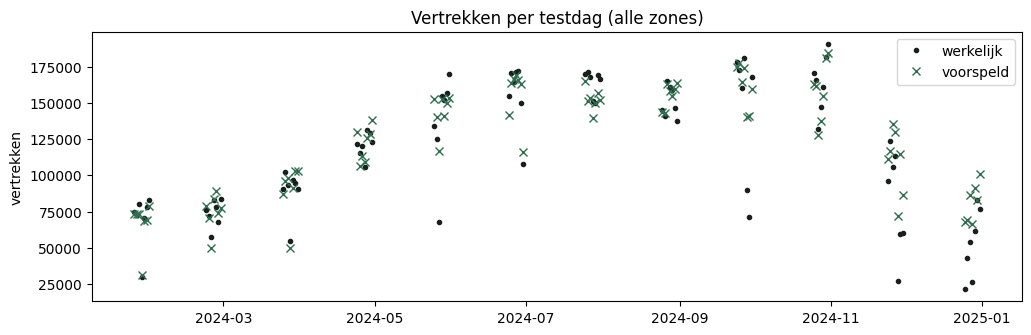

,trips,pred,rain,temp,error_pct
time,,,,,
2024-12-25,21562,67519.7,0.0,-3.0,213.1
2024-11-28,27089,71831.3,17.9,7.1,165.2
2024-12-28,26708,66121.5,5.5,4.4,147.6
2024-09-29,71242,140897.9,1.4,17.3,97.8
2024-11-29,59764,114781.8,0.1,4.0,92.1
2024-05-27,67735,116686.9,44.6,19.0,72.3
2024-12-26,42682,69396.8,0.0,-5.1,62.6
2024-12-27,54073,86247.8,0.0,-3.5,59.5


In [8]:
daily = res.groupby(res["time"].dt.normalize()).agg(trips=("trips", "sum"), pred=("pred", "sum"),
                                                    rain=("precipitation_mm", "mean"), temp=("temperature_c", "mean"))
daily["error_pct"] = (daily["pred"] / daily["trips"] - 1) * 100
daily["rain"] = daily["rain"] * 24          # gemiddelde mm per uur -> mm per dag (zelfde weer voor alle zones)
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(daily.index, daily["trips"], ".", color="#17201b", label="werkelijk")
ax.plot(daily.index, daily["pred"], "x", color="#2f6f4f", label="voorspeld")
ax.set(title="Vertrekken per testdag (alle zones)", ylabel="vertrekken")
ax.legend()
plt.show()
daily.reindex(daily["error_pct"].abs().sort_values(ascending=False).index).head(8).round(1)

**Interpretatie:** dit is de belangrijkste vondst van de foutenanalyse. De dagen waarop het model het verst naast zit, zijn bijna allemaal **feestdagen en de dagen errond**:
- **Kerstmis** (25/12): 3 keer te veel voorspeld (21.562 echte vertrekken). Ook 26, 27 en 28 december worden 60–150% overschat;
- **Thanksgiving** (28/11, met bovendien 18 mm regen) en de dag erna (**Black Friday**, 29/11);
- **Memorial Day** (27/5), met 45 mm regen.

**Waarom?** Het model kent alleen een vlag `is_holiday` voor officiële feestdagen. In de trainset zitten daarvan vooral "halve" feestdagen (Columbus Day, Veterans Day, Presidents Day) waarop veel mensen gewoon werken: het leert dus een klein effect (het GLM schatte −17%). Kerstmis en Thanksgiving zijn veel extremer, en vallen **allebei in de testset** (de laatste week van hun maand). Ook de **kerstvakantie** (26–31 december) en de dag na Thanksgiving zijn geen officiële feestdag, dus het model ziet ze als gewone werkdagen.

Daarnaast staat **29 september** in de lijst: half zoveel vertrekken als voorspeld, terwijl de weerdata maar 1,4 mm regen tonen. Waarom het die dag zo rustig was, kunnen we uit deze data niet afleiden: mogelijk regende het lokaal meer dan op het meetpunt van het weermodel.

Dit verklaart ook waarom de testfout (29,0) hoger is dan de CV-fout (24,9): de testweken bevatten toevallig de moeilijkste dagen van het jaar.

### Neerslag: leert het model het regen-effect goed?

In [9]:
res["rain_class"] = pd.cut(res["precipitation_mm"], [-0.01, 0, 0.5, 2, 100], labels=["droog", "≤0,5 mm", "0,5–2 mm", ">2 mm"])
res.groupby("rain_class", observed=True).agg(uren=("trips", "size"), werkelijk=("trips", "mean"),
                                             voorspeld=("pred", "mean"), mae=("abs_error", "mean")).round(2)

,uren,werkelijk,voorspeld,mae
rain_class,,,,
droog,50850,171.90,179.35,27.64
"≤0,5 mm",5970,130.35,131.92,32.33
"0,5–2 mm",2580,89.67,105.93,38.54
>2 mm,1080,88.28,96.15,54.44


**Interpretatie:** het model leert het regen-effect, maar **onderschat** het. Bij 0,5–2 mm per uur voorspelt het gemiddeld 106 vertrekken waar er 90 zijn (18% te veel), bij meer dan 2 mm 96 in plaats van 88. De fout bij zware regen (54) is dubbel zo groot als bij droog weer (28). Natte uren zijn zeldzaam (6% van de uren), dus het model heeft er weinig voorbeelden van. Bovendien meten we het weer op één punt, terwijl een bui maar een deel van de stad kan raken.

## 4. Welke kenmerken zijn belangrijk? (permutation importance)
We husselen één kolom van de testset door elkaar en meten hoeveel de MAE stijgt. Een kenmerk waar het model niets mee doet, kost niets als het gehusseld wordt. Dit is eerlijker dan de *impurity importance* van bomen, en werkt voor elk model.

In [10]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

params = metrics[best_name]["params"]
X_train, y_train, _, X_test, y_test = cb.train_test(table, cb.FEATURES_2024)
model = HistGradientBoostingRegressor(loss="poisson", categorical_features=[cb.FEATURES_2024.index("zone")],
                                      random_state=cb.SEED, **params).fit(X_train, y_train)
imp = permutation_importance(model, X_test, y_test, scoring="neg_mean_absolute_error", n_repeats=5, random_state=cb.SEED)
pd.Series(imp.importances_mean, index=cb.FEATURES_2024).sort_values(ascending=False).round(3).rename("MAE-stijging")

hour                98.347
zone                82.477
temperature_c       26.087
weekday             19.859
month               10.260
precipitation_mm     6.322
is_holiday           1.159
is_weekend          -0.037
wind_kmh            -0.247
Name: MAE-stijging, dtype: float64

**Interpretatie:**
- **Uur** (+98) en **zone** (+82) zijn veruit het belangrijkst: het dagritme per plaats (02 §9).
- Dan **temperatuur** (+26), **weekdag** (+20) en **maand** (+10).
- **Neerslag** (+6) lijkt klein, maar het regent zelden. Wanneer het regent, maakt het wel een groot verschil (zie hierboven).
- **Feestdag** (+1) is klein, omdat er maar een handvol feestdagen in de testset zitten.
- **Wind** en **weekend** dragen **niets** bij (≈ 0). Weekend is overbodig naast `weekday` (het model haalt die informatie uit de weekdag zelf). Wind zou je kunnen weglaten; het kost niets, maar maakt de API ook niet beter.

## 5. Conclusie
**Gekozen techniek:** HistGradientBoosting met Poisson-verlies, getuned (05e). In `07`–`09` trainen we die techniek op alle data (2013–2026); dat model staat in de API.

| | Baseline | Poisson-GLM | Random forest | PyCaret (Extra Trees) | **HistGB getuned** |
|---|---|---|---|---|---|
| CV-MAE | 59,2 | 30,5 | 27,4 | 26,6 | **24,9** |
| Test-MAE | 59,3 | 33,2 | 30,3 | 30,6 | **29,0** |
| Test-R² | 0,72 | 0,89 | 0,90 | 0,89 | **0,91** |

**Waarom presteert het zo?** Het dagritme per zone (uur × zone) verklaart het meeste, en een boosting-model leert die interactie, samen met temperatuur, seizoen en regen, zonder dat we ze zelf moeten bouwen. De Poisson-verliesfunctie past bij tellingen. Gemiddeld zit het model ± 29 vertrekken per uur naast bij een gemiddelde vraag van 168, dus ± 17%.

**Waar zit het fout, en wat zou helpen?**
1. **Uitzonderlijke dagen** (Kerstmis, Thanksgiving en de dagen errond) worden sterk overschat. Een kenmerk "vakantieperiode" helpt pas als het model zulke dagen in de trainset ziet. Met **meerdere jaren** data (bv. 2023 erbij) kan het leren van vorig jaar.
2. **Regen** wordt onderschat. Weer op meerdere punten in de stad (per zone) en neerslag van het vorige uur kunnen helpen.
3. 's Nachts en in rustige zones is de relatieve fout groot, maar dat is toevalsruis bij kleine aantallen en voor herverdeling onbelangrijk.

**Echte verbetering of artefact?** De winst van boosting tegenover random forest en Extra Trees is klein (± 1,3 vertrekken per uur), maar consistent: in alle 5 folds en met een bootstrap-interval boven 0. Het lag-model is daarentegen een voorbeeld van een **misleidende** testverbetering: beter op de testset, maar slechter in elke CV-fold.